In [1]:
from pathlib import Path

import pandas as pd
import numpy as np


**Penjelasan:**

Cell ini mengimpor library utama yang dipakai untuk EDA. `pandas` digunakan untuk membaca dan mengolah data tabular, `numpy` membantu operasi numerik, dan `Path` membuat path file lebih aman dipakai lintas folder.


In [2]:
PROJECT_DIR = Path.cwd()

while PROJECT_DIR.name != "churn_prediction":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_PATH = PROJECT_DIR / "data" / "raw" / "customer_churn.csv"

DATA_PATH

WindowsPath('d:/Self Project/SumoPod API/Profile/projects/churn_prediction/data/raw/customer_churn.csv')

**Penjelasan:**

Cell ini mencari folder utama project `churn_prediction`, lalu membuat path menuju file dataset raw. Cara ini membuat notebook tetap bisa dijalankan meskipun dibuka dari folder notebook atau dari root project.


In [3]:
df = pd.read_csv(DATA_PATH)

**Penjelasan:**

Dataset customer churn dibaca dari file CSV dan disimpan ke dataframe `df`. Mulai dari cell ini, semua proses EDA dilakukan menggunakan dataframe tersebut.


In [4]:
df.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39,PROD200,Canada,1/7/2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,12/8/2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26,PROD202,Pakistan,6/10/2023,9/4/2023,3,cancelled,3/12/2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50,PROD204,India,12/9/2020,9/14/2024,0,active,8/8/2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


**Penjelasan:**

`df.head()` menampilkan lima baris pertama. Ini dipakai untuk memahami bentuk data secara cepat, seperti nama kolom, contoh nilai, dan apakah data sudah terbaca dengan benar.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             2000 non-null   str    
 1   customer_id          2000 non-null   str    
 2   age                  2000 non-null   int64  
 3   product_id           2000 non-null   str    
 4   country              2000 non-null   str    
 5   signup_date          2000 non-null   str    
 6   last_purchase_date   2000 non-null   str    
 7   cancellations_count  2000 non-null   int64  
 8   subscription_status  2000 non-null   str    
 9   order_date           2000 non-null   str    
 10  unit_price           2000 non-null   float64
 11  quantity             2000 non-null   int64  
 12  purchase_frequency   2000 non-null   int64  
 13  preferred_category   2000 non-null   str    
 14  product_name         2000 non-null   str    
 15  category             2000 non-null   str    
 16 

**Penjelasan:**

`df.info()` menunjukkan jumlah baris, jumlah kolom, tipe data, dan jumlah nilai non-null. Ini penting untuk mendeteksi missing values dan menentukan kolom mana yang perlu dikonversi, misalnya kolom tanggal.


In [6]:
df.columns

Index(['order_id', 'customer_id', 'age', 'product_id', 'country',
       'signup_date', 'last_purchase_date', 'cancellations_count',
       'subscription_status', 'order_date', 'unit_price', 'quantity',
       'purchase_frequency', 'preferred_category', 'product_name', 'category',
       'gender'],
      dtype='str')

**Penjelasan:**

Cell ini menampilkan semua nama kolom. Dari sini kita bisa mengidentifikasi kandidat target churn, fitur numerik, fitur kategorikal, ID, dan kolom tanggal.


In [7]:
df.shape

(2000, 17)

**Penjelasan:**

`df.shape` menunjukkan ukuran dataset dalam format `(jumlah_baris, jumlah_kolom)`. Dataset ini memiliki 2.000 baris dan 17 kolom, cukup ringan untuk EDA dan model baseline.


In [8]:
# Check missing value
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values

order_id               0
customer_id            0
age                    0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
order_date             0
unit_price             0
quantity               0
purchase_frequency     0
preferred_category     0
product_name           0
category               0
gender                 0
dtype: int64

**Penjelasan:**

Cell ini menghitung missing values di setiap kolom. Hasilnya membantu menentukan apakah perlu imputasi, penghapusan baris, atau treatment khusus sebelum modeling.


In [9]:
# Check duplication
df.duplicated().sum()

np.int64(0)

**Penjelasan:**

Cell ini menghitung jumlah baris duplikat. Jika ada duplikasi, data bisa membuat analisis dan model menjadi bias karena record yang sama dihitung lebih dari sekali.


In [10]:
# Numerical statistic
df.describe()

,age,cancellations_count,unit_price,quantity,purchase_frequency
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,44.080500,2.441500,324.719460,4.948500,25.158000
std,14.798091,1.702359,361.548405,2.557757,14.158752
min,18.000000,0.000000,2.850000,1.000000,1.000000
25%,31.000000,1.000000,111.127500,3.000000,13.000000
50%,45.000000,2.000000,206.515000,5.000000,25.000000
75%,57.000000,4.000000,384.507500,7.000000,37.000000
max,69.000000,5.000000,1991.630000,9.000000,49.000000


**Penjelasan:**

`df.describe()` memberikan statistik ringkas untuk kolom numerik, seperti mean, median, minimum, maksimum, dan kuartil. Ini berguna untuk memahami skala data dan mendeteksi potensi outlier.


In [11]:
#Categorical statistic
df.describe(include="object")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20484\3499519453.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,order_id,customer_id,product_id,country,signup_date,last_purchase_date,subscription_status,order_date,preferred_category,product_name,category,gender
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,2000,2000,6,926,1078,3,1106,5,40,5,3
top,ORD5000,CUST1000,PROD200,Germany,4/10/2023,9/16/2023,active,10/16/2023,Clothing,Sneakers,Clothing,Female
freq,1,1,1,360,8,7,1204,7,419,72,426,1015


**Penjelasan:**

`df.describe(include="object")` merangkum kolom kategorikal/teks, seperti jumlah nilai unik dan kategori yang paling sering muncul. Ini membantu memahami fitur seperti negara, gender, kategori produk, dan status subscription.


In [12]:
#Check unique value
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    

order_id: 2000 unique values
customer_id: 2000 unique values
age: 52 unique values
product_id: 2000 unique values
country: 6 unique values
signup_date: 926 unique values
last_purchase_date: 1078 unique values
cancellations_count: 6 unique values
subscription_status: 3 unique values
order_date: 1106 unique values
unit_price: 1968 unique values
quantity: 9 unique values
purchase_frequency: 49 unique values
preferred_category: 5 unique values
product_name: 40 unique values
category: 5 unique values
gender: 3 unique values


**Penjelasan:**

Cell ini menghitung jumlah unique value untuk setiap kolom. Kolom dengan unique value sangat tinggi biasanya adalah ID, sedangkan kolom dengan sedikit unique value biasanya cocok untuk fitur kategorikal atau target.


In [13]:
# Get random sample
df.sample(5, random_state=42)


,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
1860,ORD6860,CUST2860,35,PROD2060,Pakistan,2/17/2023,12/17/2024,0,active,9/12/2024,300.08,4,25,Electronics,Conditioner,Beauty,Other
353,ORD5353,CUST1353,34,PROD553,Germany,3/20/2021,9/9/2022,2,cancelled,4/28/2021,214.73,7,49,Electronics,Tablet,Electronics,Female
1333,ORD6333,CUST2333,55,PROD1533,UK,9/10/2020,12/12/2022,1,active,6/20/2021,690.54,2,34,Sports,Jeans,Clothing,Male
905,ORD5905,CUST1905,40,PROD1105,USA,9/7/2020,7/12/2025,4,active,1/23/2021,23.66,7,46,Home,Jeans,Clothing,Female
1289,ORD6289,CUST2289,64,PROD1489,Pakistan,3/4/2023,9/26/2024,5,cancelled,10/21/2023,115.36,6,5,Electronics,Camera,Electronics,Female


**Penjelasan:**

`df.sample()` mengambil contoh baris secara acak. Ini membantu melihat variasi data yang mungkin tidak muncul di lima baris pertama.


In [14]:
print(df.shape)
print(missing_values)
print(df.duplicated().sum())
print(df.describe())
df.describe(include="object")

(2000, 17)
order_id               0
customer_id            0
age                    0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
order_date             0
unit_price             0
quantity               0
purchase_frequency     0
preferred_category     0
product_name           0
category               0
gender                 0
dtype: int64
0
               age  cancellations_count   unit_price     quantity  \
count  2000.000000          2000.000000  2000.000000  2000.000000   
mean     44.080500             2.441500   324.719460     4.948500   
std      14.798091             1.702359   361.548405     2.557757   
min      18.000000             0.000000     2.850000     1.000000   
25%      31.000000             1.000000   111.127500     3.000000   
50%      45.000000             2.000000   206.515000     5.000000   
75%      57.000000             4.000000   384.507500     7.000000 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20484\306571269.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,order_id,customer_id,product_id,country,signup_date,last_purchase_date,subscription_status,order_date,preferred_category,product_name,category,gender
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,2000,2000,6,926,1078,3,1106,5,40,5,3
top,ORD5000,CUST1000,PROD200,Germany,4/10/2023,9/16/2023,active,10/16/2023,Clothing,Sneakers,Clothing,Female
freq,1,1,1,360,8,7,1204,7,419,72,426,1015


**Penjelasan:**

Cell ini merangkum beberapa pemeriksaan awal dalam satu tempat: ukuran data, missing values, duplikasi, statistik numerik, dan statistik kategorikal. Bagian ini berguna sebagai checkpoint kualitas data.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

**Penjelasan:**

Cell ini mengimpor library visualisasi. `matplotlib` digunakan sebagai dasar plotting, sedangkan `seaborn` membuat chart statistik lebih mudah dan lebih rapi. Theme `whitegrid` membantu pembacaan chart.


In [17]:
df["subscription_status"].value_counts()

subscription_status
active       1204
cancelled     493
paused        303
Name: count, dtype: int64

**Penjelasan:**

Cell ini menghitung jumlah customer untuk setiap nilai `subscription_status`. Kolom ini dipakai sebagai kandidat target churn karena menunjukkan apakah customer masih aktif atau sudah berhenti/cancel.


In [19]:
churn_rate = df["subscription_status"].value_counts(normalize=True).mul(100).round(2)

churn_rate

subscription_status
active       60.20
cancelled    24.65
paused       15.15
Name: proportion, dtype: float64

**Penjelasan:**

Cell ini menghitung proporsi setiap status subscription dalam persen. Proporsi target penting untuk melihat apakah dataset seimbang atau imbalance. Dalam churn prediction, imbalance sering terjadi dan bisa memengaruhi pemilihan metric.


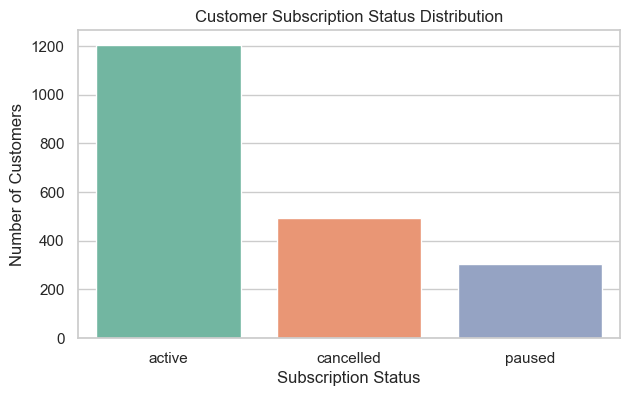

In [20]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x="subscription_status",
    hue="subscription_status",
    palette="Set2",
    legend=False
)

plt.title("Customer Subscription Status Distribution")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Customers")
plt.show()

**Penjelasan:**

Chart ini menampilkan distribusi target `subscription_status`. Tujuannya untuk melihat seberapa banyak customer aktif dibandingkan customer churn/cancel, sehingga kita memahami baseline masalah klasifikasi.


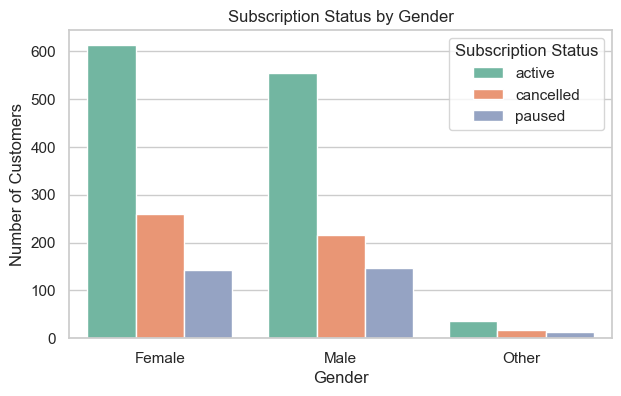

In [21]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x="gender",
    hue="subscription_status",
    palette="Set2"
)

plt.title("Subscription Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Subscription Status")
plt.show()

**Penjelasan:**

Chart ini membandingkan subscription status berdasarkan gender. Jika salah satu gender memiliki churn lebih tinggi, fitur gender bisa menjadi sinyal dalam analisis segmentasi, meskipun harus tetap digunakan secara hati-hati dalam konteks bisnis.


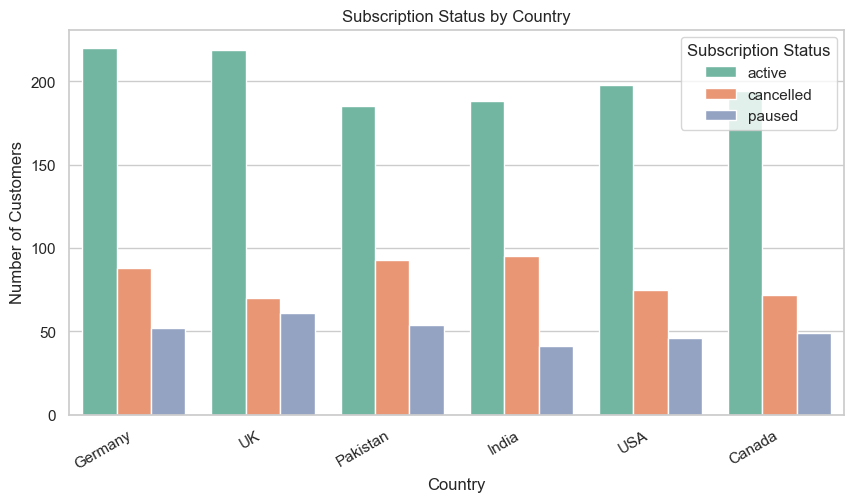

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="country",
    hue="subscription_status",
    palette="Set2",
    order=df["country"].value_counts().index
)

plt.title("Subscription Status by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Subscription Status")
plt.show()

**Penjelasan:**

Chart ini membandingkan subscription status berdasarkan country. Tujuannya untuk melihat apakah risiko churn berbeda antar negara, yang nantinya bisa dipakai untuk rekomendasi campaign berdasarkan region.


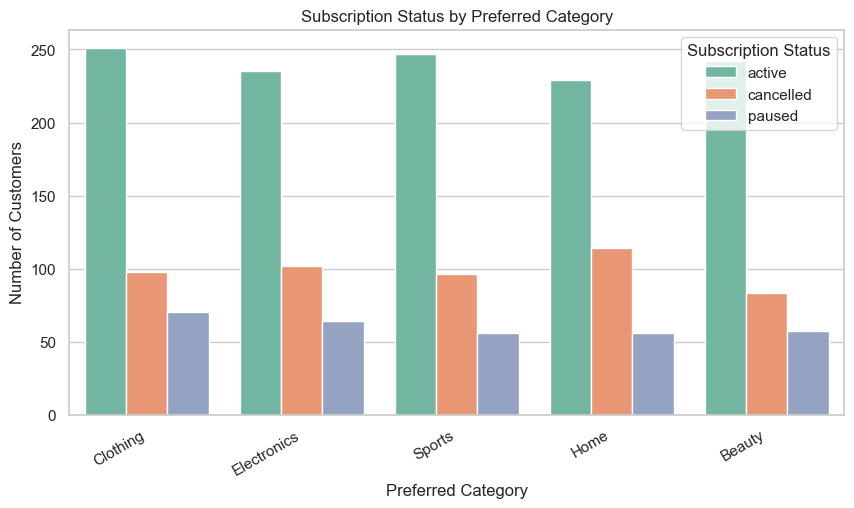

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="preferred_category",
    hue="subscription_status",
    palette="Set2",
    order=df["preferred_category"].value_counts().index
)

plt.title("Subscription Status by Preferred Category")
plt.xlabel("Preferred Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Subscription Status")
plt.show()

**Penjelasan:**

Chart ini melihat hubungan antara preferred category dan subscription status. Ini membantu menjawab apakah preferensi kategori produk tertentu berkaitan dengan churn atau loyalitas customer.


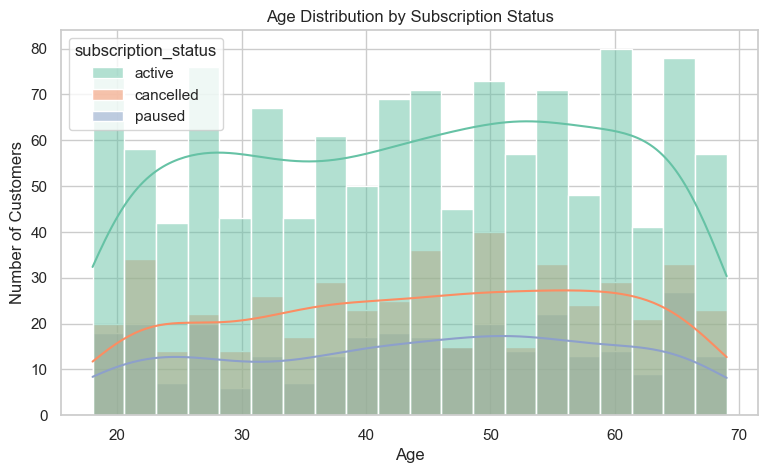

In [24]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x="age",
    hue="subscription_status",
    bins=20,
    kde=True,
    palette="Set2"
)

plt.title("Age Distribution by Subscription Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

**Penjelasan:**

Histogram ini menunjukkan distribusi umur berdasarkan subscription status. Jika pola umur customer churn berbeda dari customer aktif, age bisa menjadi fitur yang berguna dalam model.


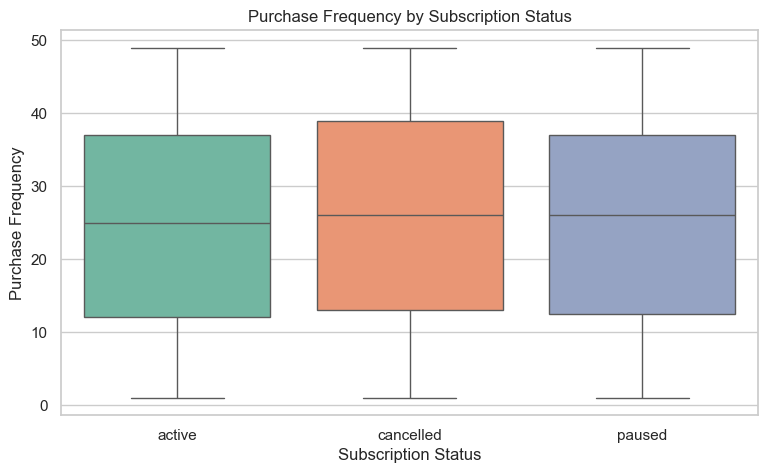

In [26]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="subscription_status",
    y="purchase_frequency",
    hue="subscription_status",
    palette="Set2",
    legend=False
)

plt.title("Purchase Frequency by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Purchase Frequency")
plt.show()

**Penjelasan:**

Boxplot ini membandingkan purchase frequency antar status subscription. Secara bisnis, customer dengan frekuensi pembelian rendah sering lebih berisiko churn, sehingga fitur ini penting untuk diperiksa.


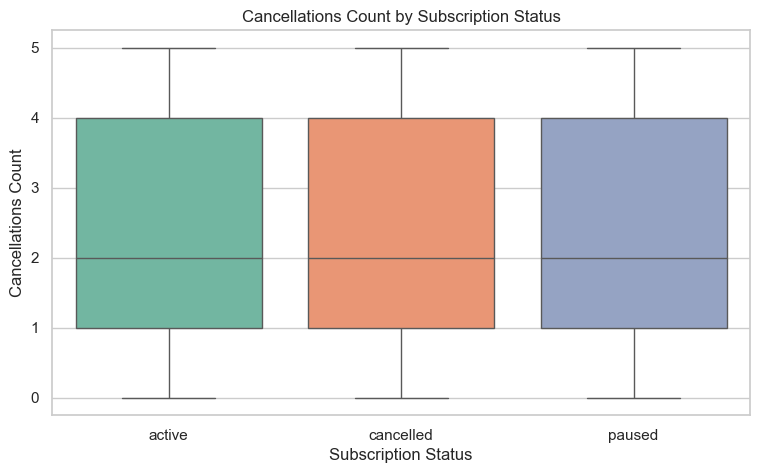

In [27]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="subscription_status",
    y="cancellations_count",
    hue="subscription_status",
    palette="Set2",
    legend=False
)

plt.title("Cancellations Count by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Cancellations Count")
plt.show()

**Penjelasan:**

Boxplot ini melihat hubungan antara jumlah pembatalan dan subscription status. Banyaknya cancellation bisa menjadi sinyal ketidakpuasan atau risiko churn yang lebih tinggi.


In [28]:
date_columns = ["signup_date", "last_purchase_date", "order_date"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df[date_columns].dtypes

signup_date           datetime64[us]
last_purchase_date    datetime64[us]
order_date            datetime64[us]
dtype: object

**Penjelasan:**

Cell ini mengubah kolom tanggal menjadi tipe `datetime`. Konversi ini wajib dilakukan sebelum membuat fitur berbasis waktu seperti tenure dan recency.


In [29]:
reference_date = df["order_date"].max()

df["customer_tenure_days"] = (reference_date - df["signup_date"]).dt.days
df["days_since_last_purchase"] = (reference_date - df["last_purchase_date"]).dt.days

df[["customer_tenure_days", "days_since_last_purchase"]].describe()

,customer_tenure_days,days_since_last_purchase
count,2000.000000,2000.000000
mean,1285.946500,630.225000
std,313.306412,410.964947
min,731.000000,0.000000
25%,1016.000000,284.000000
50%,1299.000000,585.000000
75%,1557.250000,906.000000
max,1826.000000,1795.000000


**Penjelasan:**

Cell ini membuat dua fitur penting untuk churn analysis: `customer_tenure_days` dan `days_since_last_purchase`. Tenure menunjukkan lama customer sejak signup, sedangkan recency menunjukkan berapa lama sejak pembelian terakhir.


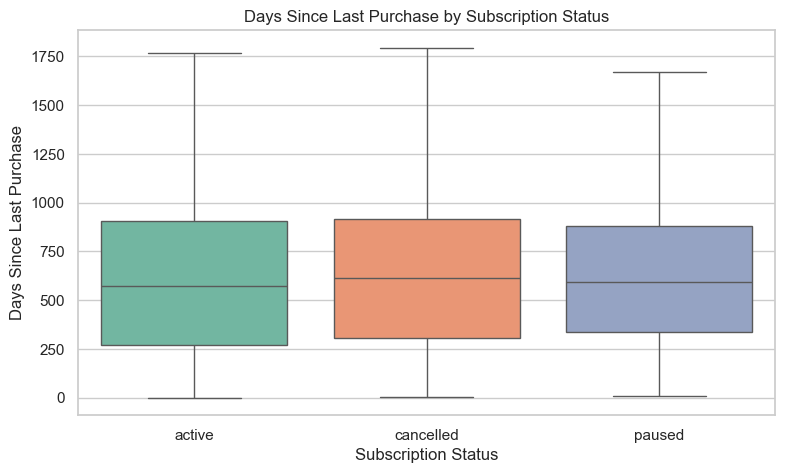

In [30]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="subscription_status",
    y="days_since_last_purchase",
    hue="subscription_status",
    palette="Set2",
    legend=False
)

plt.title("Days Since Last Purchase by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Days Since Last Purchase")
plt.show()

**Penjelasan:**

Boxplot ini membandingkan recency antar subscription status. Jika customer churn cenderung memiliki `days_since_last_purchase` lebih tinggi, berarti lama tidak membeli bisa menjadi sinyal churn.


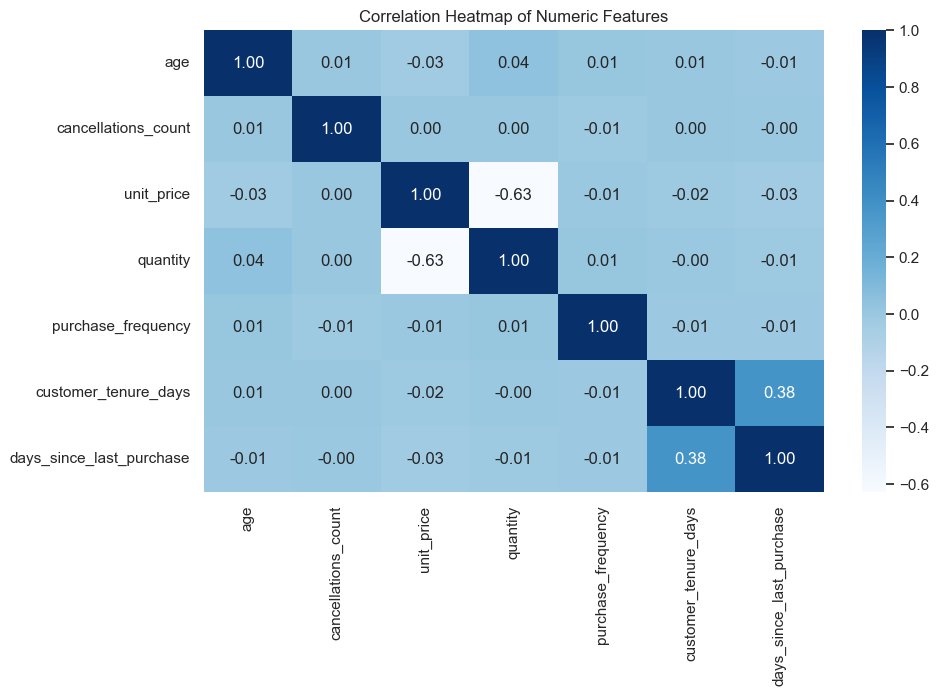

In [31]:
numeric_cols = [
    "age",
    "cancellations_count",
    "unit_price",
    "quantity",
    "purchase_frequency",
    "customer_tenure_days",
    "days_since_last_purchase",
]

plt.figure(figsize=(10, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Penjelasan:**

Heatmap ini menunjukkan korelasi antar fitur numerik. Korelasi membantu memahami hubungan antar fitur dan mendeteksi fitur yang mungkin saling mirip atau membawa informasi yang berdekatan.
